In [82]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/models/sanilawijesekara/ricevision-bilstm-v1/tensorflow2/default/1/ricevision_v7_district_aware.keras
/kaggle/input/datasets/sanilawijesekara/preprocessed-pixel-data-sl/preprocessed_pixel_data.parquet
/kaggle/input/datasets/sanilawijesekara/harvest-data-sl/2023_Yala.csv
/kaggle/input/datasets/sanilawijesekara/harvest-data-sl/2025_Maha.csv
/kaggle/input/datasets/sanilawijesekara/harvest-data-sl/2022_Yala.csv
/kaggle/input/datasets/sanilawijesekara/harvest-data-sl/2024_Maha.csv
/kaggle/input/datasets/sanilawijesekara/harvest-data-sl/2022_Maha.csv
/kaggle/input/datasets/sanilawijesekara/harvest-data-sl/2024_Yala.csv
/kaggle/input/datasets/sanilawijesekara/harvest-data-sl/2023_Maha.csv


In [83]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
import joblib

# 1. LOAD PREPROCESSED DATA & MODEL
df_processed = pd.read_parquet('/kaggle/input/datasets/sanilawijesekara/preprocessed-pixel-data-sl/preprocessed_pixel_data.parquet')
df_processed.head()


,pixel_id,date,year,month,season,district,ndvi_median_smooth,lswi_median_smooth,evi_median_smooth,ndwi_median_smooth,...,ndvi_zscore,cpi,hazard_drought,hazard_flood,hazard_heavy_rain,hazard_landslide,hazard_lightning,hazard_wind,cycle_id,is_growing
0,0,2022-01-07,2022,1,Maha,Matara,1.250850,0.839788,0.848179,-0.529858,...,-0.360078,0.0,0,0,0,0,0,0,2021_2022_Maha,0.0
1,62,2022-01-07,2022,1,Maha,Matara,2.180379,1.895706,1.505236,-1.920431,...,1.363526,0.0,0,0,0,0,0,0,2021_2022_Maha,0.0
2,102,2022-01-07,2022,1,Maha,Matara,-0.192122,1.117808,-0.765827,0.291873,...,-3.035747,0.0,0,0,0,0,0,0,2021_2022_Maha,0.0
3,63,2022-01-07,2022,1,Maha,Matara,1.207122,1.322892,1.399018,-1.936199,...,-0.441161,0.0,0,0,0,0,0,0,2021_2022_Maha,0.0
4,48,2022-01-07,2022,1,Maha,Matara,2.067244,1.725098,1.599569,-1.599543,...,1.153743,0.0,0,0,0,0,0,0,2021_2022_Maha,0.0


In [84]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2578121 entries, 0 to 2578120
Data columns (total 37 columns):
 #   Column              Dtype         
---  ------              -----         
 0   pixel_id            int64         
 1   date                datetime64[ns]
 2   year                int64         
 3   month               int64         
 4   season              object        
 5   district            object        
 6   ndvi_median_smooth  float64       
 7   lswi_median_smooth  float64       
 8   evi_median_smooth   float64       
 9   ndwi_median_smooth  float64       
 10  bsi_median_smooth   float64       
 11  ndvi_vel_z          float64       
 12  lswi_vel_z          float64       
 13  rain_7d_mean        float64       
 14  rain_14d_mean       float64       
 15  tmean_mean          float64       
 16  bsi_z               float64       
 17  rh_mean_mean        float64       
 18  delta_days          float64       
 19  doy_sin             float64       
 20  do

In [85]:
model_path = '/kaggle/input/models/sanilawijesekara/ricevision-bilstm-v1/tensorflow2/default/1/ricevision_v7_district_aware.keras'
full_model = tf.keras.models.load_model(model_path, compile=False)

In [86]:
full_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ temporal_input      │ (None, 10, 25)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 10, 25)    │          0 │ temporal_input[0… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 10, 256)   │    157,696 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ district_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 256)   │    526,080 │ bidirectional[0]… │
│ (MultiHeadAttentio… │                   │            │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 12)     │        312 │ district_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 256)   │          0 │ bidirectional[0]… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 12)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 256)   │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 19)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      1,280 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 512)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64)        │        256 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 576)       │          0 │ concatenate[0][0… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 835,967 (3.19 MB)

 Trainable params: 835,839 (3.19 MB)

 Non-trainable params: 128 (512.00 B)

In [87]:
# 1. SETUP & MAPPING
STAGE_MAP = {0: 'Transplant', 1: 'Vegetative', 2: 'Reproductive', 3: 'Ripening', 4: 'Harvest'}

In [88]:
# 2. DEFINITIONS (Matches your sequencing logic)
base_ts = ['ndvi_median_smooth', 'lswi_median_smooth', 'evi_median_smooth', 'ndwi_median_smooth', 'bsi_median_smooth', 'ndvi_vel_z', 'lswi_vel_z', 'bsi_z', 'ndvi_zscore', 'rain_7d_mean', 'rain_14d_mean', 'tmean_mean', 'rh_mean_mean', 'delta_days', 'doy_sin', 'doy_cos', 'is_growing']
hazard_cols = ['hazard_drought', 'hazard_flood', 'hazard_heavy_rain', 'hazard_landslide', 'hazard_lightning', 'hazard_wind']
ts_features = base_ts + hazard_cols + ['flood_index', 'ndvi_delta']
static_features = ['lat', 'lon', 'elevation', 'slope', 'season_id', 'doy_sin', 'doy_cos']

def fast_sequencing_yield(df, window_size=10):
    df = df.sort_values(['pixel_id', 'cycle_id', 'date']).reset_index(drop=True)
    df['group_id'] = df.groupby(['pixel_id', 'cycle_id']).ngroup()
    
    # Physics Features
    df['flood_index'] = df['lswi_median_smooth'] - df['ndvi_median_smooth']
    df['ndvi_delta'] = df.groupby('pixel_id')['ndvi_median_smooth'].diff().fillna(0)
    df['season_id'] = (df['season'] == 'Yala').astype('int32')
    
    ts_data = df[ts_features].values.astype('float32')
    static_data = df[static_features].values.astype('float32')
    dist_data = df['district_id'].values.astype('int32')
    group_ids = df['group_id'].values
    
    starts = np.arange(len(df) - window_size + 1)
    ends = starts + window_size - 1
    valid_mask = (group_ids[starts] == group_ids[ends])
    
    valid_starts = starts[valid_mask]
    valid_ends = ends[valid_mask]
    indices_2d = valid_starts[:, None] + np.arange(window_size)[None, :]
    
    # RETURN AS DICTIONARY to match model layer names
    X_dict = {
        "temporal_input": ts_data[indices_2d],
        "static_input": static_data[valid_ends],
        "district_input": dist_data[valid_ends]
    }
    
    # [Crucial Update]: Include weather in the meta return
    meta = df.iloc[valid_ends][['pixel_id', 'cycle_id', 'district', 'year', 'season', 
                                'tmean_mean', 'rain_7d_mean']].copy()
    return X_dict, meta

# 3. RUN INFERENCE
print("🔄 Sequencing data...")
X_input_dict, meta_df = fast_sequencing_yield(df_processed)

print("🧠 Extracting Latent Features using Dictionary Inputs...")
# We use the full_model's input layers directly to ensure names match
feature_extractor = tf.keras.Model(
    inputs=full_model.input, 
    outputs=[
        full_model.get_layer('dense_1').output, 
        full_model.get_layer('health_out').output,
        full_model.get_layer('stage_out').output
    ]
)

# Predict using the dictionary to avoid ValueError: incompatible shape
latents, health_z, stage_probs = feature_extractor.predict(X_input_dict, batch_size=2048, verbose=1)

🔄 Sequencing data...
🧠 Extracting Latent Features using Dictionary Inputs...
1086/1086 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step


In [89]:
# 4. DATA CONSOLIDATION
meta_df['health_z'] = health_z.flatten()
meta_df['stage_id'] = np.argmax(stage_probs, axis=1)

# **PCA**

In [90]:
print("📉 Compressing knowledge (PCA)...")
pca = PCA(n_components=5)
pc_feat = pca.fit_transform(latents)
for i in range(5):
    meta_df[f'pc_{i+1}'] = pc_feat[:, i]

📉 Compressing knowledge (PCA)...


# District aggregation

In [91]:
# 5. AGRONOMIC FEATURE CALCULATION (Per Pixel)
print("🌱 Calculating Agronomic Statistics (Veg/Repro durations)...")

def get_pixel_agronomics(group):
    # Filter for active growth: Vegetative (1), Reproductive (2), Ripening (3)
    growing_season = group[group['stage_id'].isin([1, 2, 3])]
    flowering_period = group[group['stage_id'] == 2]
    
    res = {}
    # Durations (Each record is 10 days)
    res['veg_days'] = (group['stage_id'] == 1).sum() * 10
    res['repro_days'] = (group['stage_id'] == 2).sum() * 10
    
    # General Health
    res['peak_health'] = growing_season['health_z'].max() if not growing_season.empty else 0
    res['auc_health'] = growing_season['health_z'].clip(0).sum()
    res['avg_health'] = growing_season['health_z'].mean() if not growing_season.empty else 0
    
    # Flowering Stress (Stage 2)
    if not flowering_period.empty:
        res['temp_flowering'] = flowering_period['tmean_mean'].mean()
        res['rain_flowering'] = flowering_period['rain_7d_mean'].mean()
        # Stress defined as health < -1.0 during flowering
        res['stress_flowering'] = (flowering_period['health_z'] < -1.0).sum()
    else:
        res['temp_flowering'] = 0
        res['rain_flowering'] = 0
        res['stress_flowering'] = 0
        
    # Deep Features (Last state of the LSTM for this pixel)
    for i in range(1, 6):
        res[f'PC{i}'] = group[f'pc_{i}'].iloc[-1]
        
    return pd.Series(res)

pixel_summary = meta_df.groupby(['pixel_id', 'cycle_id']).apply(get_pixel_agronomics).reset_index()

# Add metadata back
pixel_summary = pixel_summary.merge(
    meta_df[['pixel_id', 'cycle_id', 'district', 'year', 'season']].drop_duplicates(),
    on=['pixel_id', 'cycle_id']
)

# 6. DISTRICT AGGREGATION & XGBOOST
print("📊 Aggregating to District Level & Training...")
district_summary = pixel_summary.groupby(['district', 'year', 'season']).mean(numeric_only=True).reset_index()

🌱 Calculating Agronomic Statistics (Veg/Repro durations)...


/tmp/ipykernel_55/724686982.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pixel_summary = meta_df.groupby(['pixel_id', 'cycle_id']).apply(get_pixel_agronomics).reset_index()


📊 Aggregating to District Level & Training...


# Load government harvest data

In [92]:
import os
import glob
import pandas as pd

# --- 1. RE-DEFINING PATHS ---
# '.' tells the code to look in the folder where your notebook is running
# '/kaggle/input' tells it to look in added datasets
SEARCH_PATHS = ['.', '/kaggle/input']

print("🔍 Searching for Government Harvest CSVs...")

harvest_files = []
for path in SEARCH_PATHS:
    # We add recursive=True so it looks inside every subfolder automatically
    harvest_files += glob.glob(os.path.join(path, "**/*Maha.csv"), recursive=True)
    harvest_files += glob.glob(os.path.join(path, "**/*Yala.csv"), recursive=True)

# Remove duplicates if any
harvest_files = list(set(harvest_files))

gov_dfs = []
for f in harvest_files:
    try:
        print(f"📄 Found: {os.path.basename(f)}")
        temp = pd.read_csv(f)
        # Check if it's the right type of CSV
        if 'Average_yield_kg_per_ha' in temp.columns:
            gov_dfs.append(temp)
    except Exception as e:
        print(f"⚠️ Could not read {f}: {e}")

if gov_dfs:
    df_gov_all = pd.concat(gov_dfs, ignore_index=True)
    df_gov_all['District'] = df_gov_all['District'].str.strip().str.title()
    print(f"✅ Successfully loaded {len(df_gov_all)} yield records.")
else:
    # If it still fails, let's print everything in /kaggle/input to see where they are
    print("\n❌ STILL NO FILES FOUND. Checking directory structure for you:")
    for root, dirs, files in os.walk('/kaggle/input'):
        for file in files:
            if 'csv' in file.lower():
                print(f"Found a CSV here: {os.path.join(root, file)}")
    
    raise ValueError("❌ No Government Harvest CSVs found! Please check the names of your uploaded files.")

🔍 Searching for Government Harvest CSVs...
📄 Found: 2022_Yala.csv
📄 Found: 2023_Yala.csv
📄 Found: 2025_Maha.csv
📄 Found: 2024_Yala.csv
📄 Found: 2022_Maha.csv
📄 Found: 2023_Maha.csv
📄 Found: 2024_Maha.csv
✅ Successfully loaded 172 yield records.


# Merging datasets

In [93]:
# Merge with Government Yields (df_gov_all)
df_gov_all['District'] = df_gov_all['District'].str.strip().str.title()
final_train = pd.merge(district_summary, df_gov_all, 
                       left_on=['district', 'year', 'season'], 
                       right_on=['District', 'Year', 'Season'], how='inner')

In [94]:
final_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   district                 165 non-null    object 
 1   year                     165 non-null    int64  
 2   season                   165 non-null    object 
 3   pixel_id                 165 non-null    float64
 4   veg_days                 165 non-null    float64
 5   repro_days               165 non-null    float64
 6   peak_health              165 non-null    float64
 7   auc_health               165 non-null    float64
 8   avg_health               165 non-null    float64
 9   temp_flowering           165 non-null    float64
 10  rain_flowering           165 non-null    float64
 11  stress_flowering         165 non-null    float64
 12  PC1                      165 non-null    float64
 13  PC2                      165 non-null    float64
 14  PC3                      1

In [95]:
final_train.head()

,district,year,season,pixel_id,veg_days,repro_days,peak_health,auc_health,avg_health,temp_flowering,...,PC2,PC3,PC4,PC5,District,Year,Season,Average_yield_kg_per_ha,Harvested_extent_ha,Total_production_MT
0,Ampara,2022,Maha,1621.251272,106.539232,54.752582,0.901939,6.842034,-0.021292,-0.847574,...,-0.994216,-0.062646,-1.828828,0.825333,Ampara,2022,Maha,2857,77631,221529
1,Ampara,2022,Yala,1607.637649,64.594595,50.125707,0.945928,4.352596,-0.039154,0.235582,...,4.332715,-0.315961,-0.908302,1.030039,Ampara,2022,Yala,3708,59869,221999
2,Ampara,2023,Maha,1623.185289,222.591554,124.489637,1.381839,14.947866,-0.006680,-0.897823,...,-2.182027,-0.144264,-0.527367,-0.128902,Ampara,2023,Maha,4172,76347,318517
3,Ampara,2023,Yala,1622.000000,133.217257,82.779661,1.332580,9.916422,0.024450,1.125715,...,-3.480458,0.117272,-0.719562,0.079124,Ampara,2023,Yala,4338,60377,261938
4,Ampara,2024,Maha,1621.851589,248.327677,145.692687,1.476648,16.849490,-0.003016,-0.932013,...,-2.841823,0.538982,-0.071171,-0.292757,Ampara,2024,Maha,3933,67898,267017


In [96]:
final_train.isnull().sum()

district                   0
year                       0
season                     0
pixel_id                   0
veg_days                   0
repro_days                 0
peak_health                0
auc_health                 0
avg_health                 0
temp_flowering             0
rain_flowering             0
stress_flowering           0
PC1                        0
PC2                        0
PC3                        0
PC4                        0
PC5                        0
District                   0
Year                       0
Season                     0
Average_yield_kg_per_ha    0
Harvested_extent_ha        0
Total_production_MT        0
dtype: int64

In [97]:
final_train.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
district,165,24,Ampara,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,165.0,NaN,NaN,NaN,2023.290909,1.036047,2022.0,2022.0,2023.0,2024.0,2025.0
season,165,2,Maha,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pixel_id,165.0,NaN,NaN,NaN,596.495661,584.594943,9.0,120.0,492.798682,1019.213041,2093.346069
veg_days,165.0,NaN,NaN,NaN,277.916478,153.009567,61.763971,158.298755,244.824399,409.89603,578.984375
repro_days,165.0,NaN,NaN,NaN,140.744104,66.789736,49.423373,96.366412,122.448133,160.26971,288.930481
peak_health,165.0,NaN,NaN,NaN,1.448477,0.235641,0.863008,1.286108,1.469406,1.626301,1.990278
auc_health,165.0,NaN,NaN,NaN,19.023896,10.482891,4.296799,10.23016,16.515062,26.40295,46.243228
avg_health,165.0,NaN,NaN,NaN,0.000865,0.034289,-0.082154,-0.020939,-0.001101,0.02098,0.162926
temp_flowering,165.0,NaN,NaN,NaN,-0.304773,0.819211,-1.286166,-0.960133,-0.88105,0.601963,1.131426


# Preprocessing merged data

In [98]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
import joblib

df_final = final_train.copy()

df_final.drop(columns=['season'], inplace = True)
# 1. ENCODING CATEGORIES
# Season: Maha=0, Yala=1
df_final['Season_ID'] = df_final['Season'].map({'Maha': 0, 'Yala': 1})

# District: Convert names to numbers
le_dist = LabelEncoder()
df_final['District_ID'] = le_dist.fit_transform(df_final['District'])
df_final.head()

,district,year,pixel_id,veg_days,repro_days,peak_health,auc_health,avg_health,temp_flowering,rain_flowering,...,PC4,PC5,District,Year,Season,Average_yield_kg_per_ha,Harvested_extent_ha,Total_production_MT,Season_ID,District_ID
0,Ampara,2022,1621.251272,106.539232,54.752582,0.901939,6.842034,-0.021292,-0.847574,0.059095,...,-1.828828,0.825333,Ampara,2022,Maha,2857,77631,221529,0,0
1,Ampara,2022,1607.637649,64.594595,50.125707,0.945928,4.352596,-0.039154,0.235582,-0.092422,...,-0.908302,1.030039,Ampara,2022,Yala,3708,59869,221999,1,0
2,Ampara,2023,1623.185289,222.591554,124.489637,1.381839,14.947866,-0.006680,-0.897823,0.130170,...,-0.527367,-0.128902,Ampara,2023,Maha,4172,76347,318517,0,0
3,Ampara,2023,1622.000000,133.217257,82.779661,1.332580,9.916422,0.024450,1.125715,-0.379825,...,-0.719562,0.079124,Ampara,2023,Yala,4338,60377,261938,1,0
4,Ampara,2024,1621.851589,248.327677,145.692687,1.476648,16.849490,-0.003016,-0.932013,0.204954,...,-0.071171,-0.292757,Ampara,2024,Maha,3933,67898,267017,0,0


In [99]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   district                 165 non-null    object 
 1   year                     165 non-null    int64  
 2   pixel_id                 165 non-null    float64
 3   veg_days                 165 non-null    float64
 4   repro_days               165 non-null    float64
 5   peak_health              165 non-null    float64
 6   auc_health               165 non-null    float64
 7   avg_health               165 non-null    float64
 8   temp_flowering           165 non-null    float64
 9   rain_flowering           165 non-null    float64
 10  stress_flowering         165 non-null    float64
 11  PC1                      165 non-null    float64
 12  PC2                      165 non-null    float64
 13  PC3                      165 non-null    float64
 14  PC4                      1

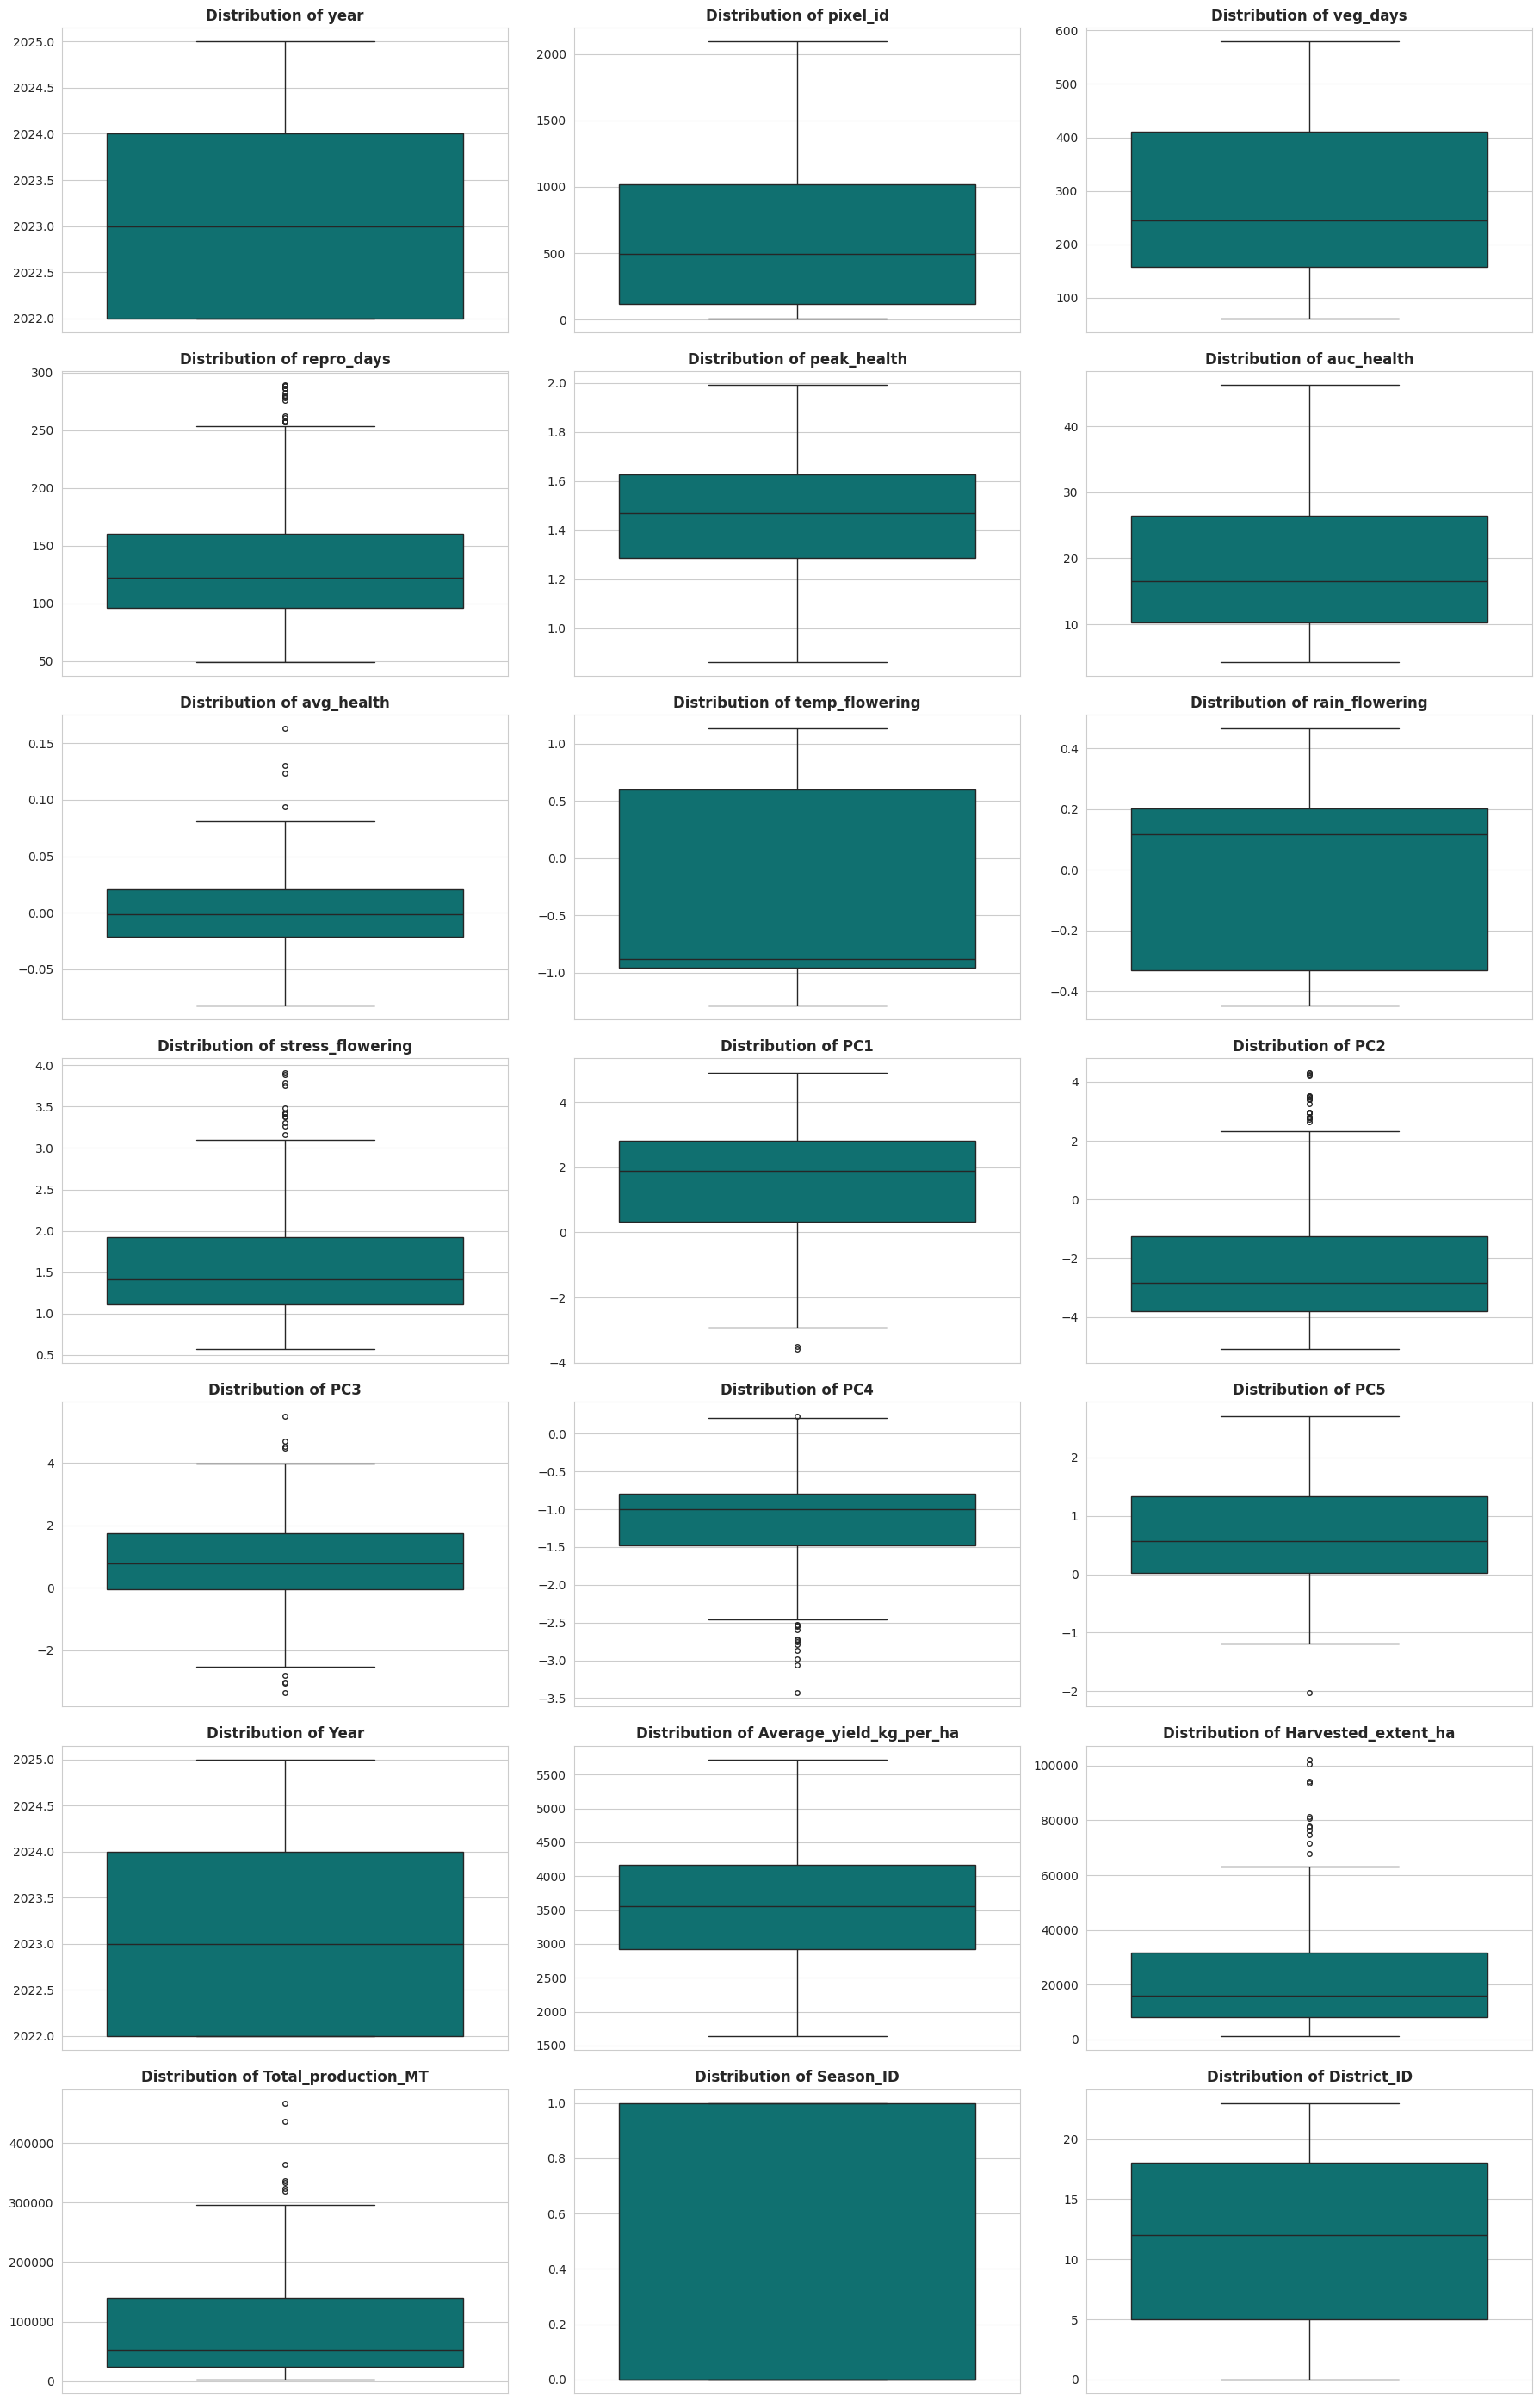

✅ Boxplots generated for 21 numeric columns.


In [101]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Identify numerical columns automatically
# This ignores 'district', 'District', and 'Season'
numeric_cols = df_final.select_dtypes(include=['number']).columns.tolist()

# 2. Setup the grid layout (3 columns per row)
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

# 3. Create the plots
plt.figure(figsize=(18, 4 * n_rows))
sns.set_style("whitegrid")

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df_final[col], color='teal', fliersize=4)
    plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    plt.ylabel('') # Clean up the axis
    plt.tight_layout()

# 4. Save and Show
plt.savefig('feature_boxplots.png', dpi=300)
plt.show()

print(f"✅ Boxplots generated for {len(numeric_cols)} numeric columns.")

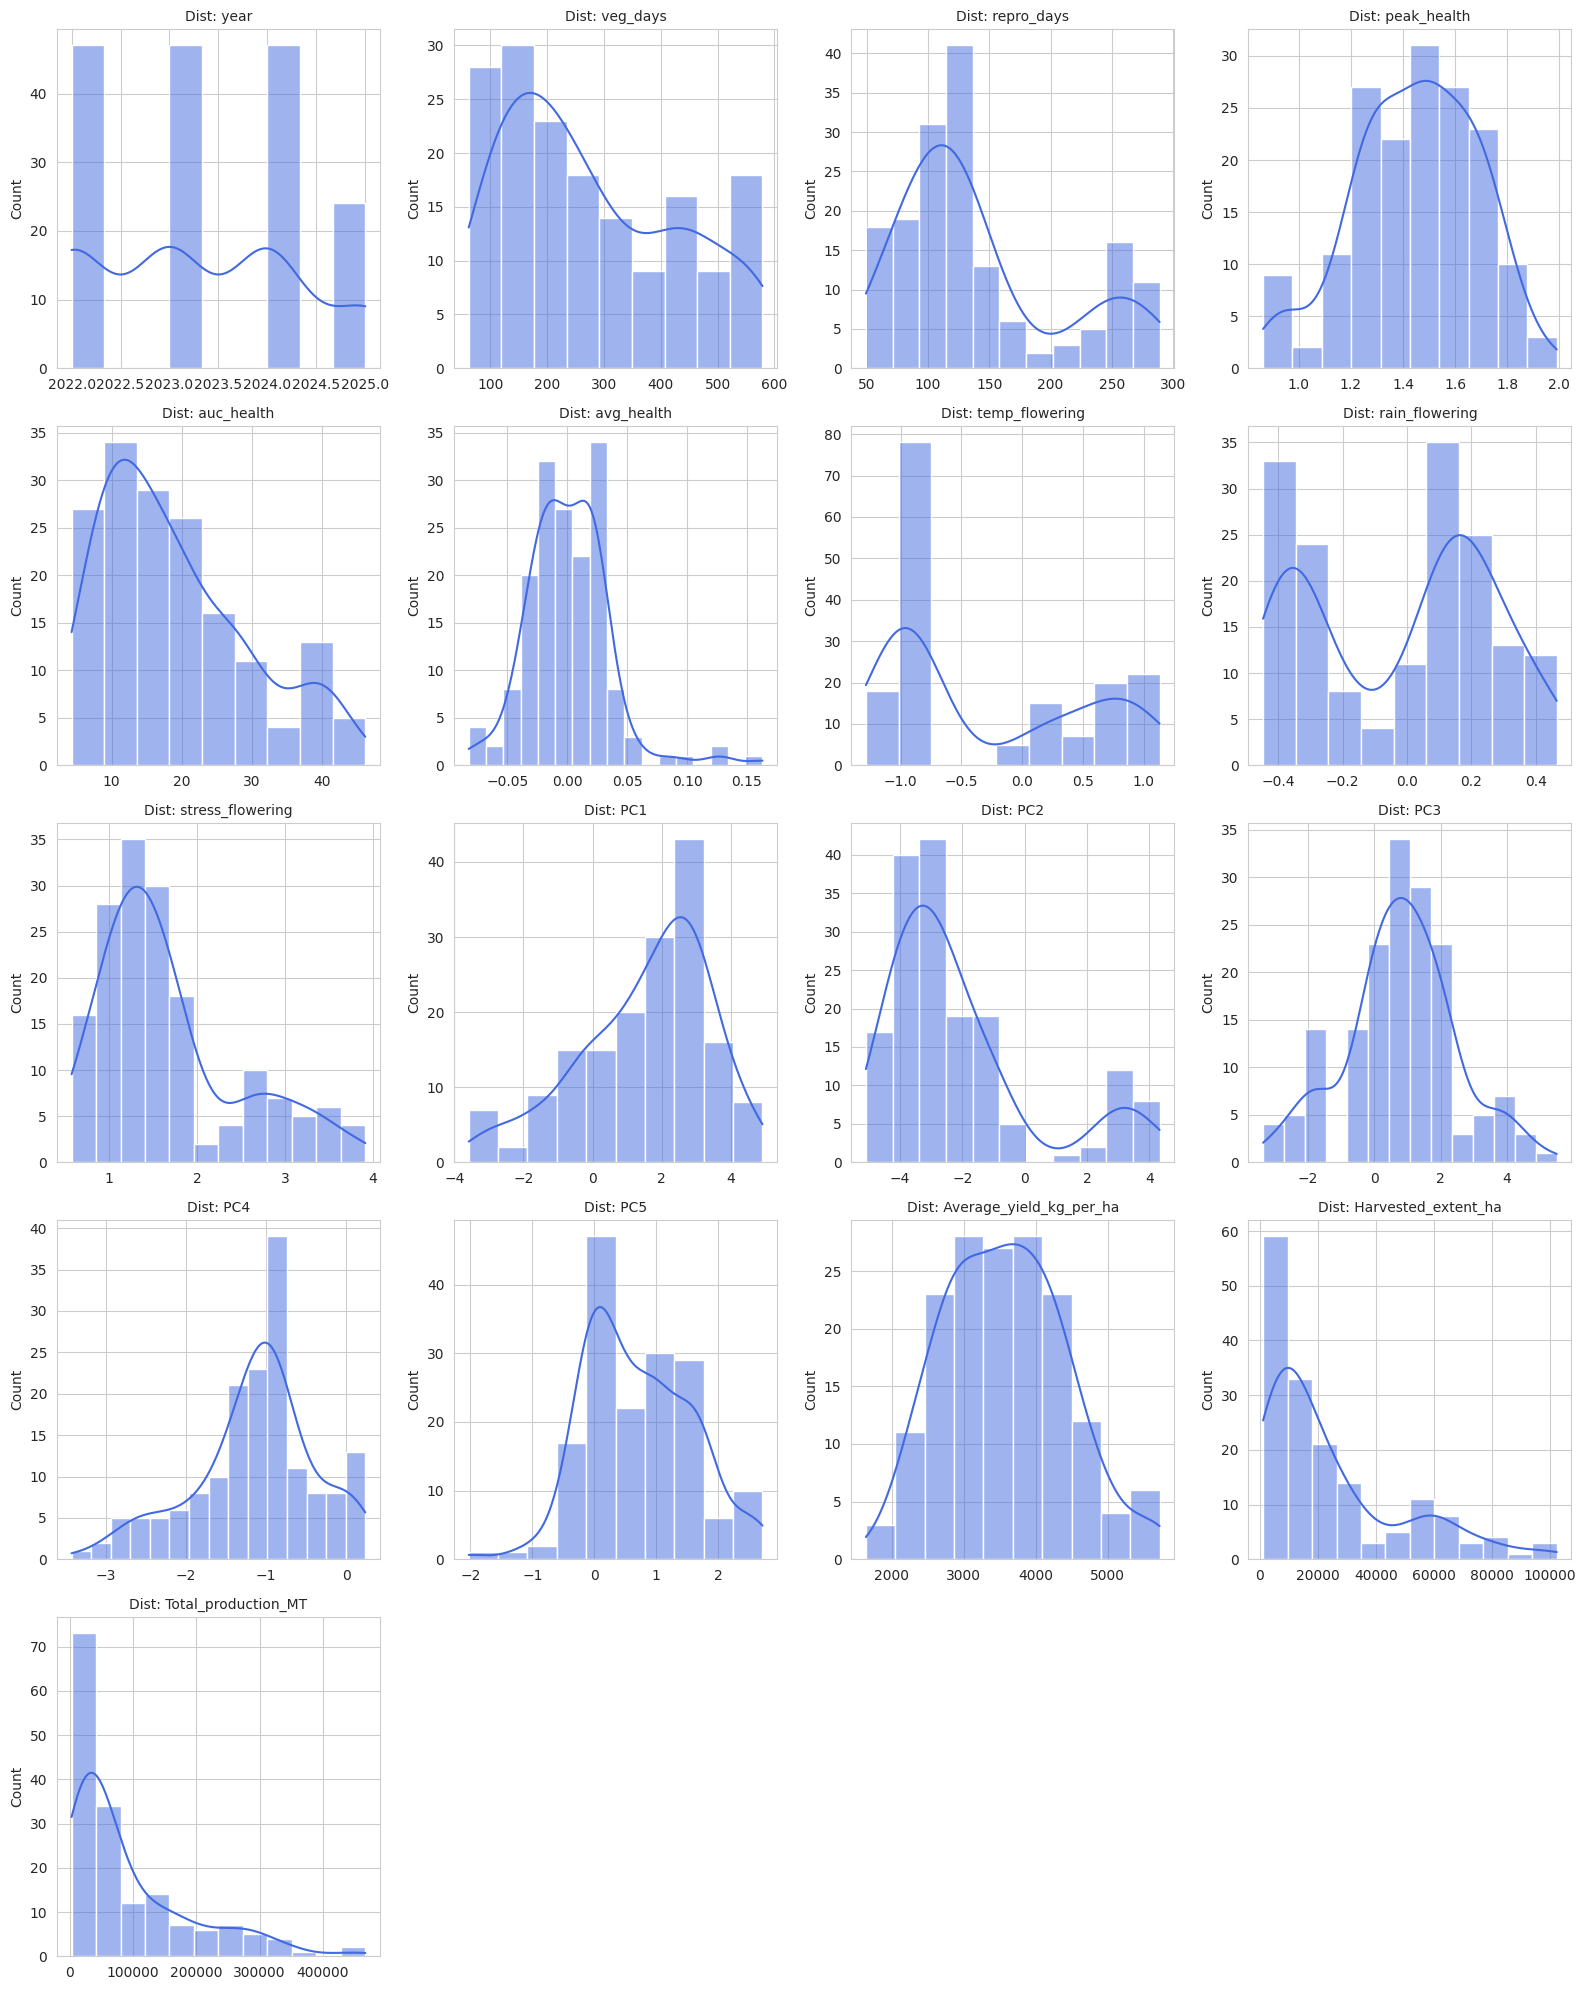

In [105]:
import math

# 1. Identify numeric columns
numeric_cols = df_final.select_dtypes(include=['number']).columns.tolist()
# Filter out metadata/IDs if you don't want to see them
cols_to_plot = [c for c in numeric_cols if c not in ['Year', 'Season_ID', 'District_ID', 'pixel_id']]

# 2. Calculate grid size dynamically
num_features = len(cols_to_plot)
n_cols = 4
n_rows = math.ceil(num_features / n_cols) # Automatically determines rows (e.g., 17 features -> 5 rows)

# 3. Plot
plt.figure(figsize=(16, 4 * n_rows)) # Height scales with number of rows
for i, col in enumerate(cols_to_plot):
    plt.subplot(n_rows, n_cols, i + 1) # Now uses n_rows instead of a fixed 4
    sns.histplot(df_final[col], kde=True, color='royalblue')
    plt.title(f'Dist: {col}', fontsize=10)
    plt.xlabel('') 

plt.tight_layout()
plt.savefig("distributions.png")
plt.show()

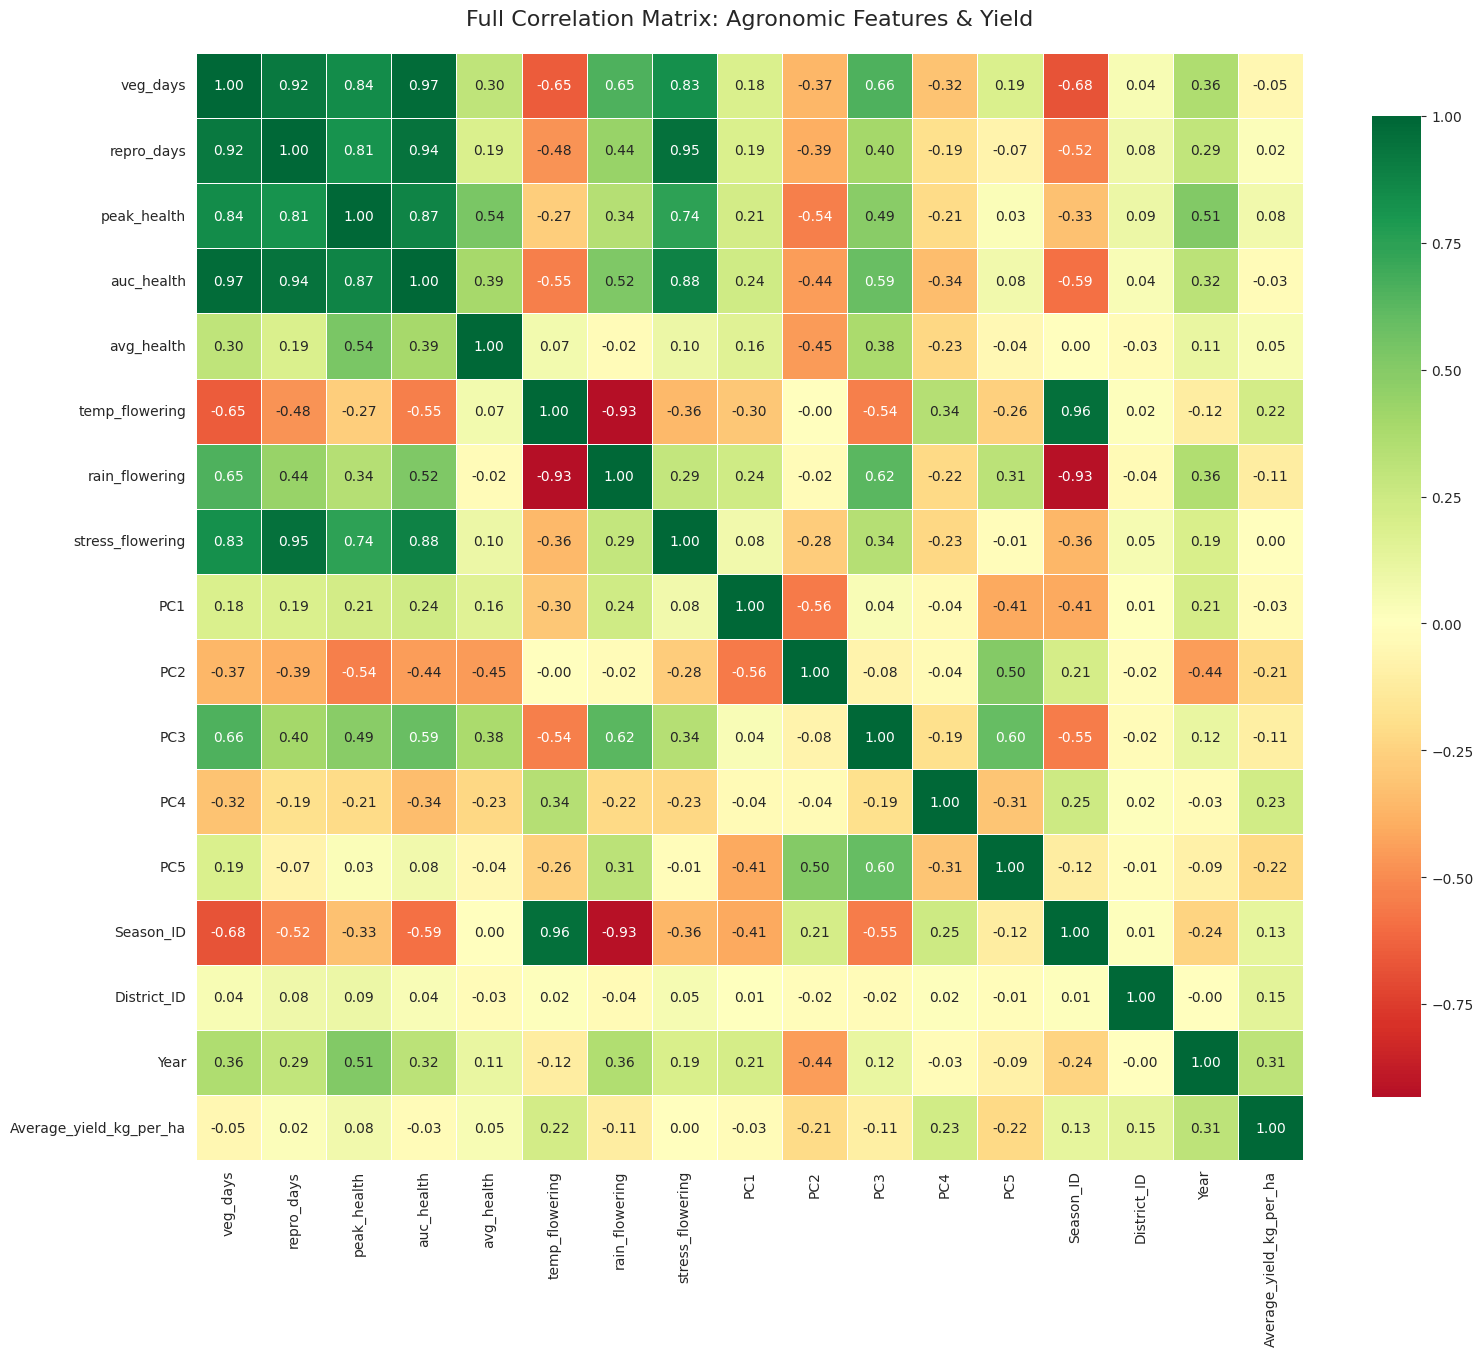

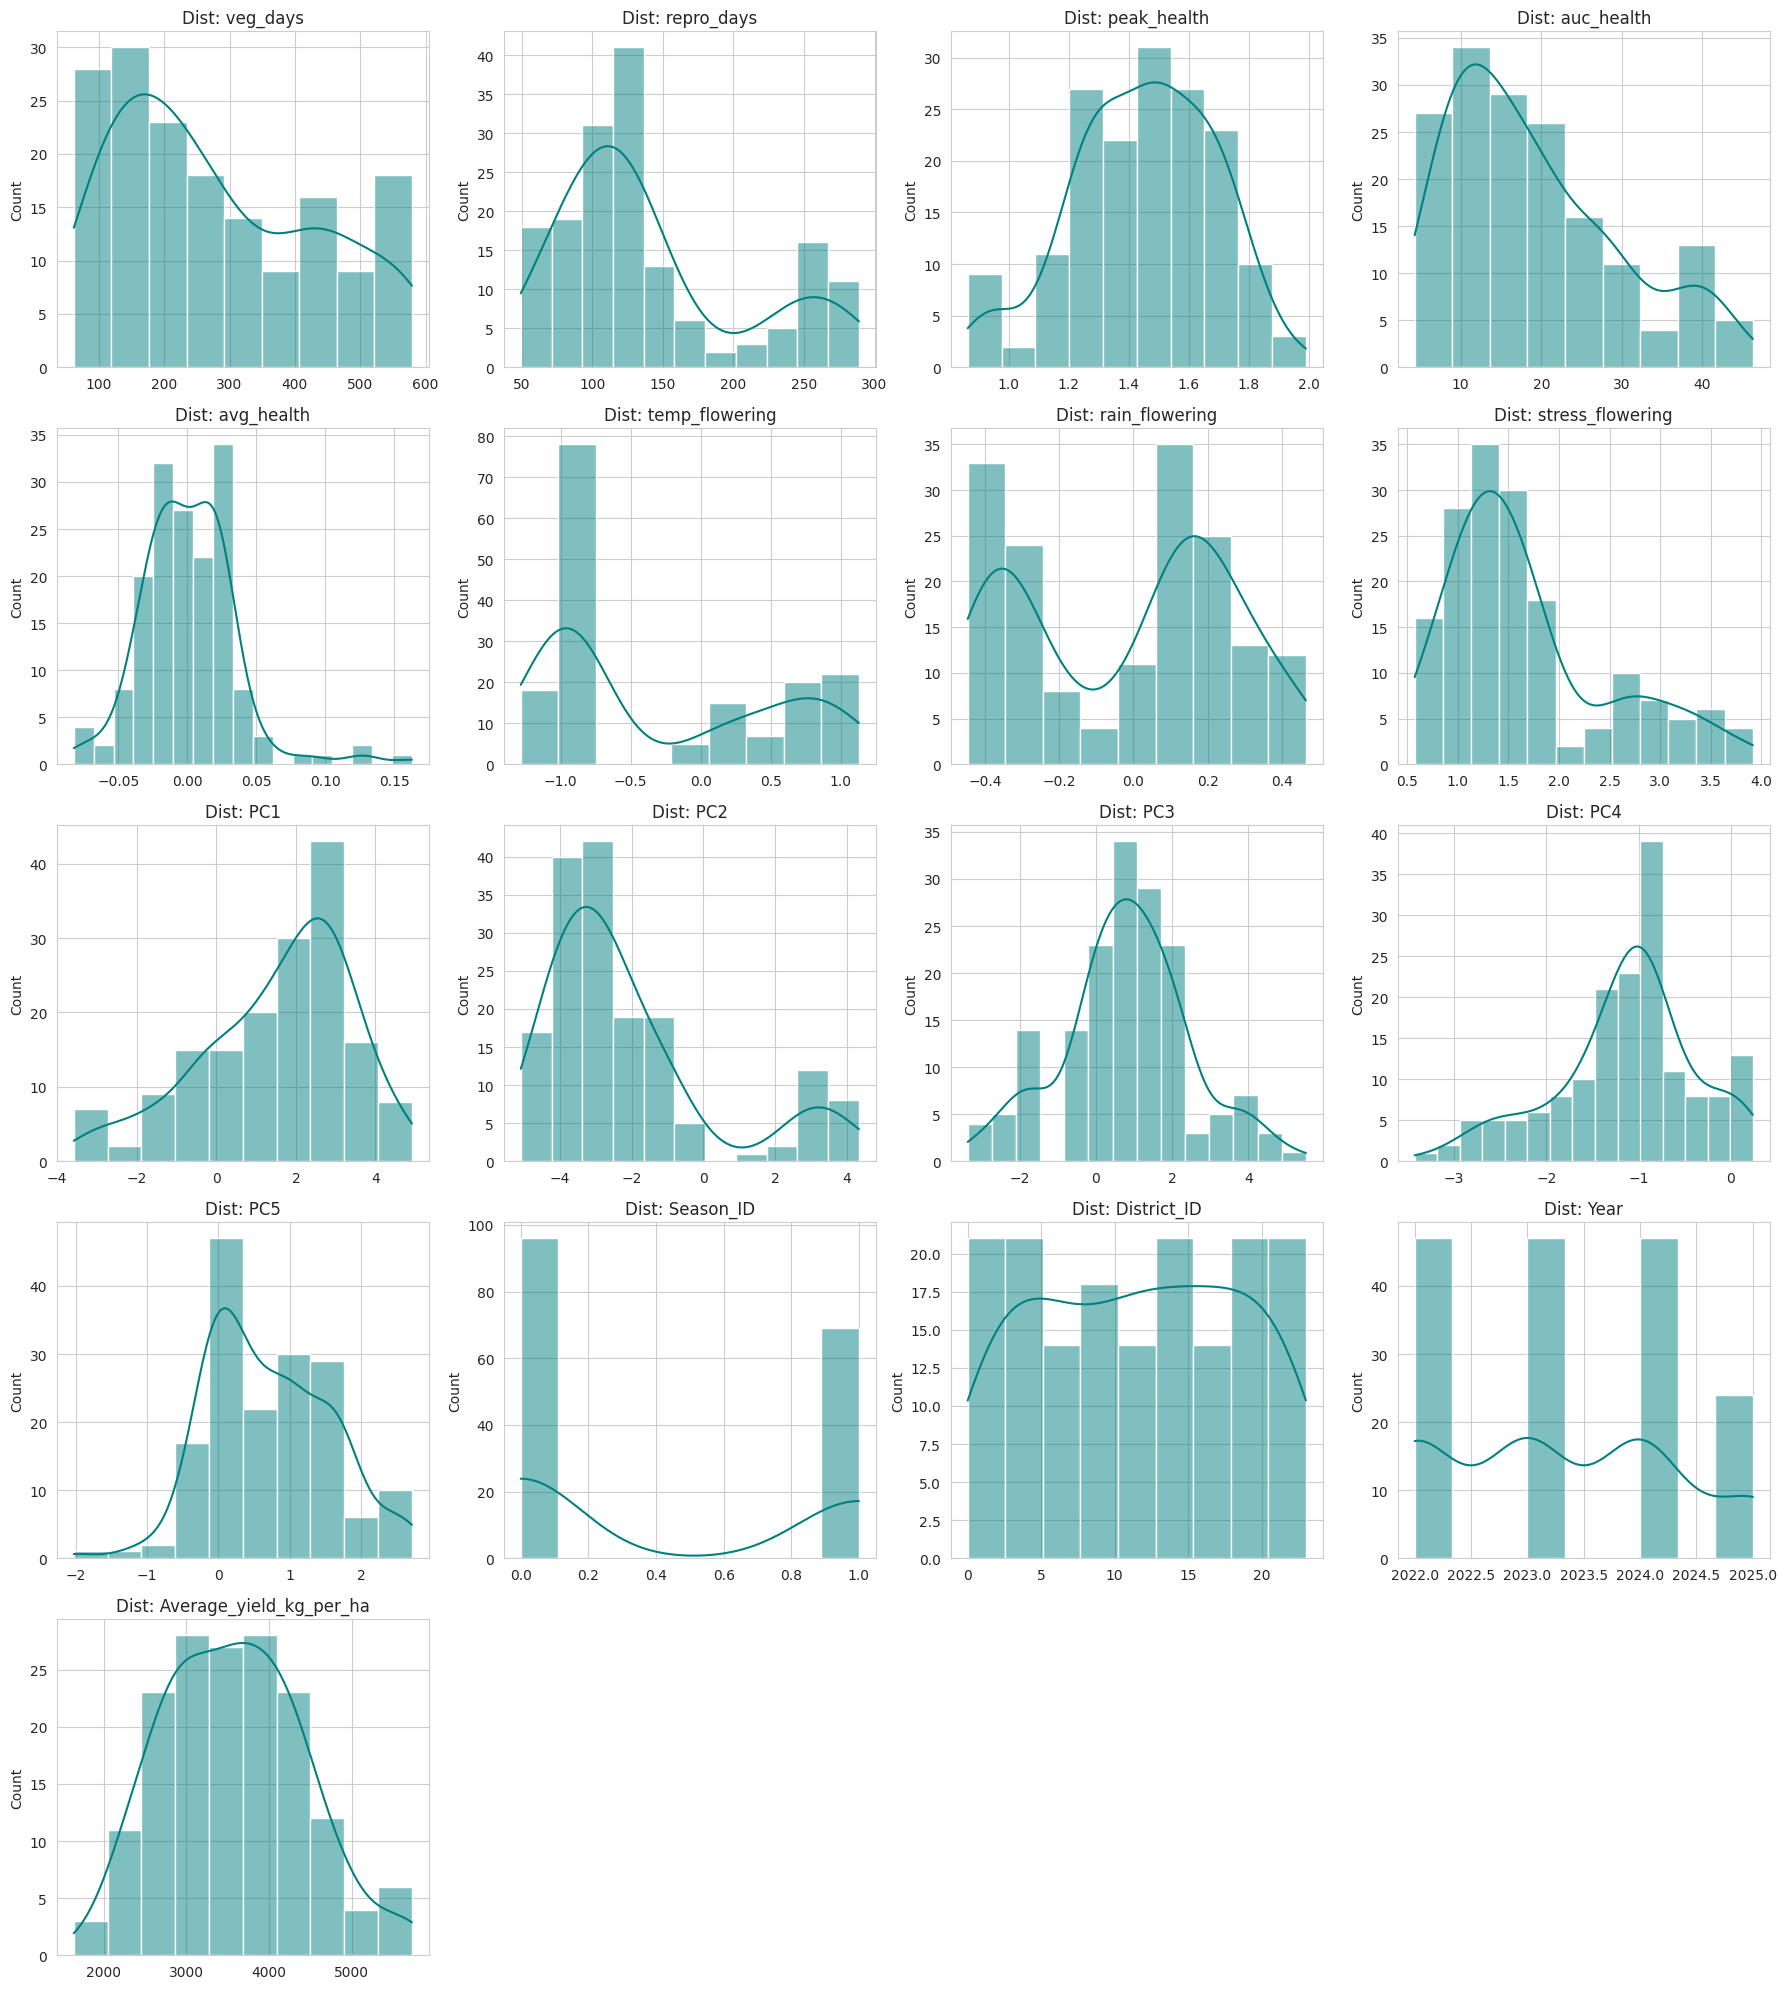

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Define the Feature List (This fixes the NameError)
features = [
    'veg_days', 'repro_days', 'peak_health', 'auc_health', 'avg_health', 
    'temp_flowering', 'rain_flowering', 'stress_flowering', 
    'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 
    'Season_ID', 'District_ID', 'Year'
]

corr_cols = features + ['Average_yield_kg_per_ha']

# 2. Filter for existing columns and compute correlation
available_cols = [c for c in corr_cols if c in df_final.columns]
corr_matrix = df_final[available_cols].corr()

# 3. Plot the Full Box Heatmap
plt.figure(figsize=(16, 14))

sns.heatmap(
    corr_matrix, 
    annot=True,           # Show the numbers
    fmt=".2f",            # 2 decimal places
    cmap='RdYlGn',        # Red (Negative) to Green (Positive)
    center=0,             # 0 is the neutral color
    square=True,          # Make cells square
    linewidths=.5,        # Add thin lines between boxes
    cbar_kws={"shrink": .8}
)

plt.title("Full Correlation Matrix: Agronomic Features & Yield", fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('full_correlation_heatmap.png', dpi=300)
plt.show()

# 3. Dynamic Distribution Plots (Histograms)
num_to_plot = len(available_cols)
n_cols = 4
n_rows = math.ceil(num_to_plot / n_cols)

plt.figure(figsize=(18, 4 * n_rows))
for i, col in enumerate(available_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df_final[col], kde=True, color='teal')
    plt.title(f'Dist: {col}', fontsize=12)
    plt.xlabel('')
    
plt.tight_layout()
plt.show()

In [108]:
df_final.to_csv("yield_final.csv")

🔍 Evaluating model performance using 5-Fold Cross-Validation...
✅ Average Error (MAE): 574.88 kg/ha
✅ Error Consistency (Std Dev): ±61.91 kg/ha

🚀 Training final model on the full dataset...
💾 Model saved as 'rice_yield_model_v1.pkl'


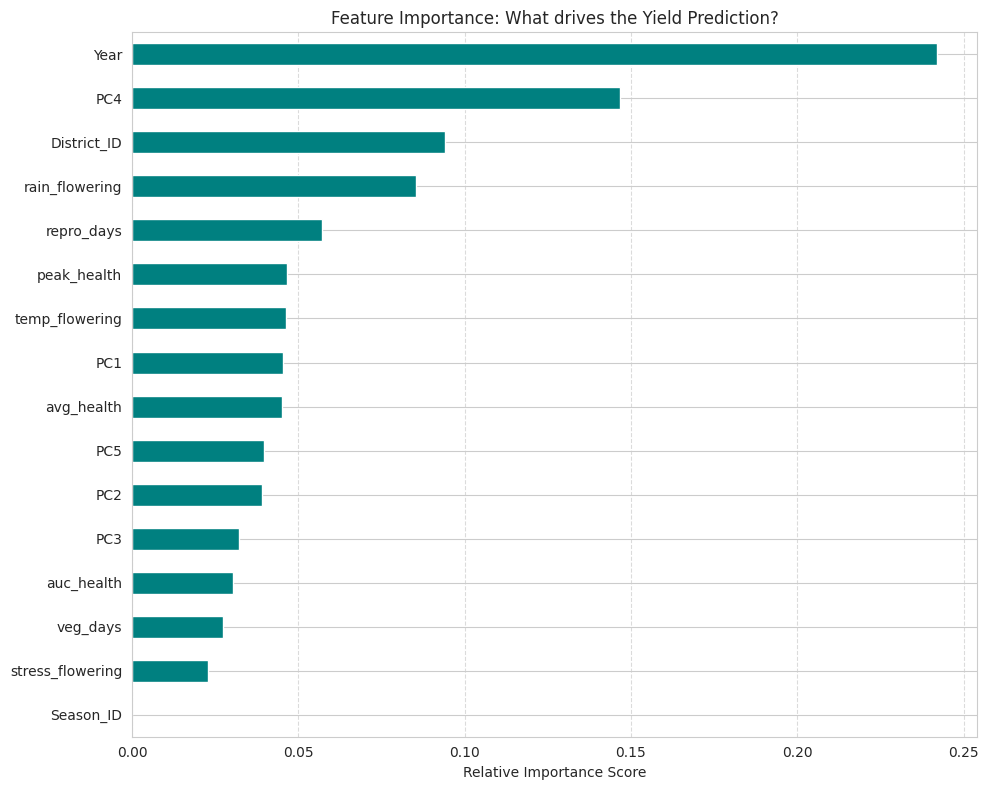

In [110]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import KFold, cross_val_score

# 1. SELECT NECESSARY COLUMNS
features = [
    'veg_days', 'repro_days', 'peak_health', 'auc_health', 'avg_health', 
    'temp_flowering', 'rain_flowering', 'stress_flowering', 
    'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 
    'Season_ID', 'District_ID', 'Year'
]
target = 'Average_yield_kg_per_ha'

# Ensure the data is ready
X = df_final[features]
y = df_final[target]

# 2. DEFINE THE MODEL
# We use conservative parameters to avoid overfitting on 165 rows
yield_model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=4,            # Limit depth for small data
    learning_rate=0.02,     # Slow learning is better for small datasets
    subsample=0.8,          # Use 80% of rows for each tree
    colsample_bytree=0.8,   # Use 80% of features for each tree
    reg_alpha=0.5,          # L1 regularization to reduce noise
    reg_lambda=1.5,         # L2 regularization to keep weights small
    random_state=42
)

# 3. EVALUATE WITH CROSS-VALIDATION
# This tells us how well the model generalizes before we trust it
print("🔍 Evaluating model performance using 5-Fold Cross-Validation...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(yield_model, X, y, cv=kf, scoring='neg_mean_absolute_error')
mae_scores = -cv_scores

print(f"✅ Average Error (MAE): {mae_scores.mean():.2f} kg/ha")
print(f"✅ Error Consistency (Std Dev): ±{mae_scores.std():.2f} kg/ha")

# 4. TRAIN FINAL MODEL ON ALL 165 ROWS
print("\n🚀 Training final model on the full dataset...")
yield_model.fit(X, y)

# 5. SAVE THE MODEL
joblib.dump(yield_model, 'rice_yield_model_v1.pkl')
print("💾 Model saved as 'rice_yield_model_v1.pkl'")

# 6. PLOT FEATURE IMPORTANCE
plt.figure(figsize=(10, 8))
importances = pd.Series(yield_model.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='teal')
plt.title("Feature Importance: What drives the Yield Prediction?")
plt.xlabel("Relative Importance Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [111]:
from sklearn.metrics import r2_score

# 1. Get predictions for the data we trained on
y_pred = yield_model.predict(X)

# 2. Calculate R-squared
r2 = r2_score(y, y_pred)

# 3. Calculate "Mean Absolute Percentage Error" (MAPE)
# This gives you a "90% accurate" style number
mape = np.mean(np.abs((y - y_pred) / y)) * 100
accuracy_pct = 100 - mape

print(f"📊 Model R^2 Score: {r2:.4f}")
print(f"🎯 Accuracy Percentage: {accuracy_pct:.2f}%")

📊 Model R^2 Score: 0.9984
🎯 Accuracy Percentage: 99.18%


In [112]:
# Train error
y_train_pred = yield_model.predict(X)
train_mae = mean_absolute_error(y, y_train_pred)

print(f"Train MAE: {train_mae:.2f} kg/ha")
print(f"CV MAE:    {mae_scores.mean():.2f} kg/ha") # From your previous code

Train MAE: 26.59 kg/ha
CV MAE:    574.88 kg/ha


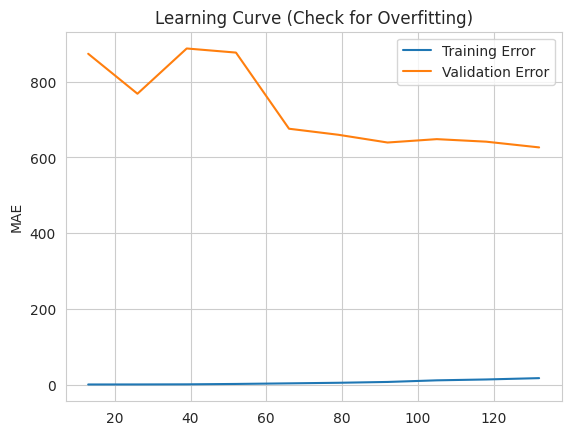

In [113]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    yield_model, X, y, cv=5, scoring='neg_mean_absolute_error', 
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.plot(train_sizes, -train_scores.mean(axis=1), label='Training Error')
plt.plot(train_sizes, -test_scores.mean(axis=1), label='Validation Error')
plt.title('Learning Curve (Check for Overfitting)')
plt.ylabel('MAE')
plt.legend()
plt.show()